In [15]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import NN.classic_nn
importlib.reload(NN.classic_nn)
from NN.classic_nn import ClassicNeuralNet

import Trainer.classic_trainer
importlib.reload(Trainer.classic_trainer)
from Trainer.classic_trainer import ClassicTrainer

import NN.genetic_nn
importlib.reload(NN.genetic_nn)

import Trainer.genetic_trainer
importlib.reload(Trainer.genetic_trainer)
from Trainer.genetic_trainer import GeneticTrainer

import NN.aco_nn
importlib.reload(NN.aco_nn)

import Trainer.aco_trainer
importlib.reload(Trainer.aco_trainer)
from Trainer.aco_trainer import ACOTrainer

import NN.kan
importlib.reload(NN.kan)
from NN.kan import KAN

import Trainer.kan_trainer
importlib.reload(Trainer.kan_trainer)
from Trainer.kan_trainer import KANTrainer

In [16]:
n = 1000
x1 = np.linspace(-np.pi, np.pi, n)
x2 = np.linspace(-np.pi, np.pi, n)
x3 = np.linspace(-np.pi, np.pi, n)
X = np.vstack((x1, x2, x3)).T
base = np.sin(x1) + np.cos(x2) - np.atan(x3)
y = (base).reshape(-1, 1)

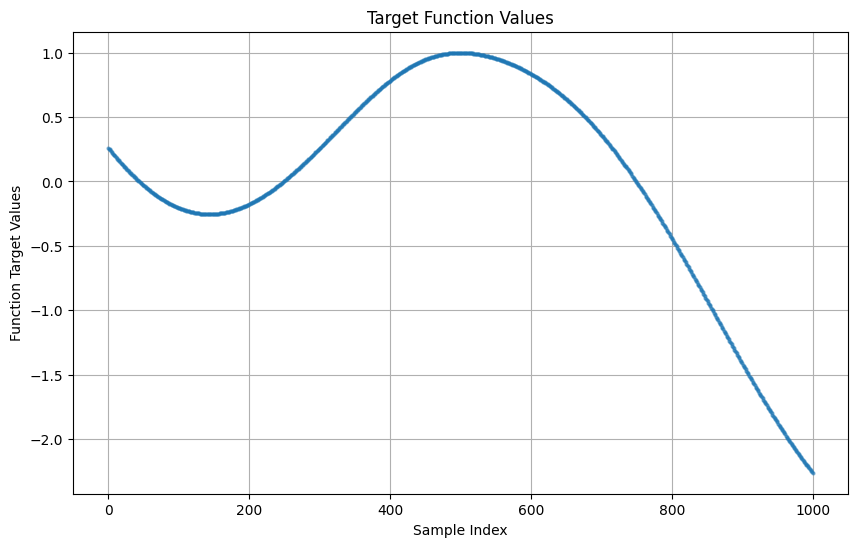

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(y, 'o', markersize=2, alpha=0.5)
plt.title('Target Function Values')
plt.xlabel('Sample Index')
plt.ylabel('Function Target Values')
plt.grid()
plt.show()

In [18]:
np.random.seed(42)

# Hyperparam condivisi
input_size = 3
hidden_size =5
output_size = 1
soglia = 0.02
max_iter = 20000
print_every = 50
kan_n_wavelets = 8
kan_wavelet = 'mexican_hat'

# Scegli qui come inizializzare i bias: 'zero' oppure 'random'
bias_init = 'random'

# Backprop
classic_model = ClassicNeuralNet(
    input_size,
    hidden_size,
    output_size,
    seed=42,
    bias_init=bias_init,
 )
classic_trainer = ClassicTrainer(classic_model, learning_rate=0.01)
y_pred_bp, losses_bp = classic_trainer.train(
    X, y, print_every=print_every, soglia=soglia, max_iter=max_iter
)

# KAN
kan_model = KAN(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    n_wavelets=kan_n_wavelets,
    wavelet=kan_wavelet,
    seed=42,
 )
kan_trainer = KANTrainer(kan_model, learning_rate=0.01)
y_pred_kan, losses_kan = kan_trainer.train(
    X, y, print_every=print_every, soglia=soglia, max_iter=max_iter
)

# Genetic: confronto tra tutte le strategie
ga_strategies = ['sort', 'torneo', 'roulette', 'roulette_sus']
ga_results = {}

for strategy in ga_strategies:
    np.random.seed(42)
    ga_trainer = GeneticTrainer(
        input_size=input_size,
        hidden_size=hidden_size,
        output_size=output_size,
        population_size=16,
        mutation_rate=0.1,
        mutation_strength=0.1,
        bias_init=bias_init,
    )

    losses = ga_trainer.train(
        X,
        y,
        print_every=print_every,
        soglia=soglia,
        max_iter=max_iter,
        strategy=strategy,
        k_torneo=4,
    )

    best_idx = int(np.argmin([ind.loss(X, y) for ind in ga_trainer.population]))
    best_individual = ga_trainer.population[best_idx]
    y_pred = best_individual.forward(X)

    ga_results[strategy] = {
        'losses': losses.copy(),
        'y_pred': y_pred,
        'forward_calls': ga_trainer.forward_calls,
    }

# ACO: training eseguito dopo GA
aco_trainer = ACOTrainer(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    n_ants=16,
    elite_fraction=0.25,
    evaporation_rate=1.0,
    pheromone_learning_rate=1.0,
    init_sigma=1.0,
    min_sigma=1e-3,
    bias_init=bias_init,
    seed=42,
 )
losses_aco = aco_trainer.train(
    X,
    y,
    print_every=print_every,
    soglia=soglia,
    max_iter=max_iter,
 )
y_pred_aco = aco_trainer.best_individual.forward(X)

Iterazione MLP  50, loss: 0.2999
Iterazione MLP  100, loss: 0.2278
Iterazione MLP  150, loss: 0.1781
Iterazione MLP  200, loss: 0.1389
Iterazione MLP  250, loss: 0.1088
Iterazione MLP  300, loss: 0.0888
Iterazione MLP  350, loss: 0.0759
Iterazione MLP  400, loss: 0.0669
Iterazione MLP  450, loss: 0.0600
Iterazione MLP  500, loss: 0.0545
Iterazione MLP  550, loss: 0.0499
Iterazione MLP  600, loss: 0.0461
Iterazione MLP  650, loss: 0.0427
Iterazione MLP  700, loss: 0.0398
Iterazione MLP  750, loss: 0.0373
Iterazione MLP  800, loss: 0.0351
Iterazione MLP  850, loss: 0.0331
Iterazione MLP  900, loss: 0.0313
Iterazione MLP  950, loss: 0.0297
Iterazione MLP  1000, loss: 0.0282
Iterazione MLP  1050, loss: 0.0269
Iterazione MLP  1100, loss: 0.0257
Iterazione MLP  1150, loss: 0.0246
Iterazione MLP  1200, loss: 0.0236
Iterazione MLP  1250, loss: 0.0227
Iterazione MLP  1300, loss: 0.0218
Iterazione MLP  1350, loss: 0.0210
Iterazione MLP  1400, loss: 0.0203
Iterazione 50, loss: 0.183190
Iterazione

In [19]:
print(f'Confronto finale con {hidden_size} nodi nel layer nascosto:')
bp_compute_units = classic_trainer.forward_calls + 2 * classic_trainer.backward_calls
kan_compute_units = kan_trainer.forward_calls + 2 * kan_trainer.backward_calls
print(
    f"Backprop -> iterazioni: {len(losses_bp)}, "
    f"loss finale: {losses_bp[-1]:.4f}, "
    f"forward_calls + 2 * backward_calls: {bp_compute_units}"
)
print(
    f"KAN ({kan_wavelet}) -> iterazioni: {len(losses_kan)}, "
    f"loss finale: {losses_kan[-1]:.4f}, "
    f"forward_calls + 2 * backward_calls: {kan_compute_units}"
)

for strategy in ga_strategies:
    losses = ga_results[strategy]['losses']
    print(
        f"GA ({strategy}) -> evoluzioni: {len(losses)}, "
        f"loss finale: {losses[-1]:.4f}, "
        f"forward calls: {ga_results[strategy]['forward_calls']}"
    )

print(
    f"ACO -> evoluzioni: {len(losses_aco)}, "
    f"loss finale: {losses_aco[-1]:.4f}, "
    f"forward calls: {aco_trainer.forward_calls}"
)

Confronto finale con 5 nodi nel layer nascosto:
Backprop -> iterazioni: 1420, loss finale: 0.0200, forward_calls + 2 * backward_calls: 4260
KAN (mexican_hat) -> iterazioni: 181, loss finale: 0.0199, forward_calls + 2 * backward_calls: 543
GA (sort) -> evoluzioni: 12757, loss finale: 0.0200, forward calls: 204112
GA (torneo) -> evoluzioni: 20000, loss finale: 0.0308, forward calls: 320000
GA (roulette) -> evoluzioni: 1029, loss finale: 0.0200, forward calls: 16464
GA (roulette_sus) -> evoluzioni: 20000, loss finale: 0.0260, forward calls: 320000
ACO -> evoluzioni: 9645, loss finale: 0.0200, forward calls: 154320


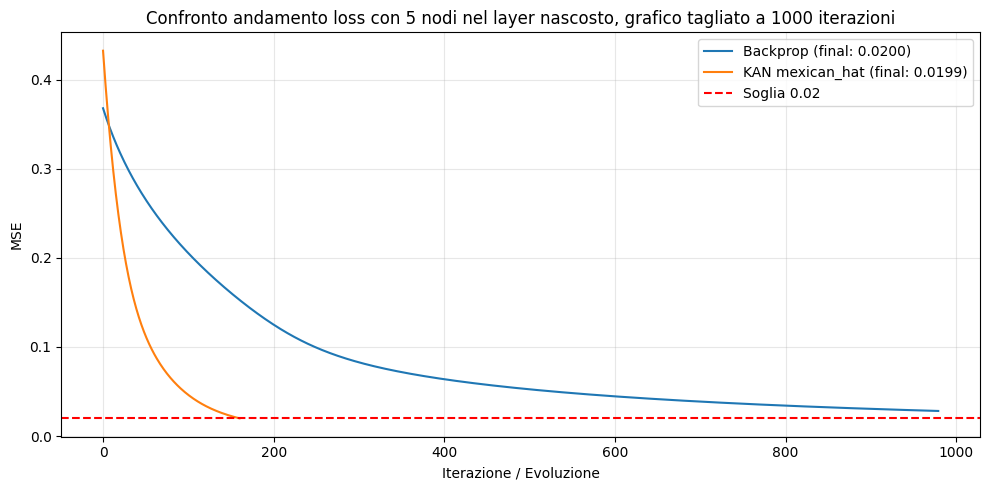

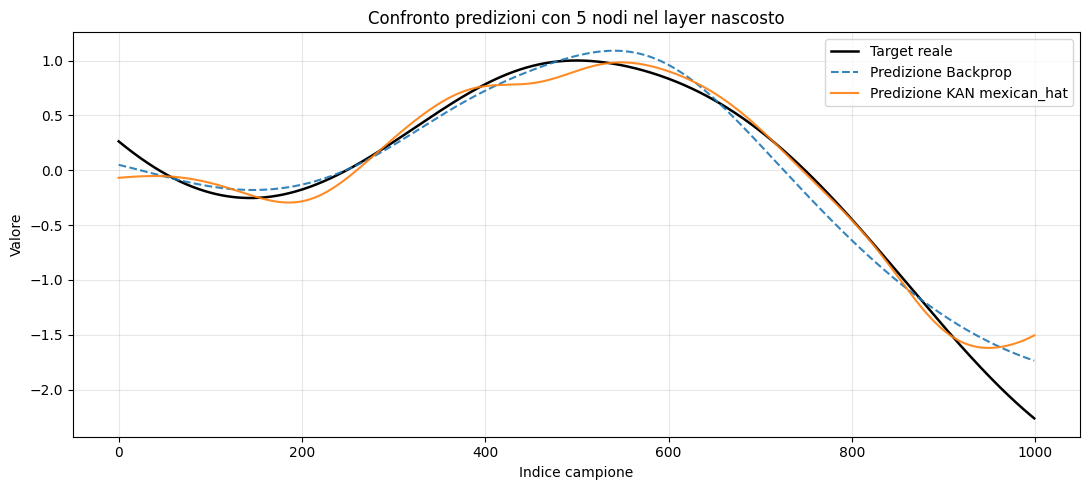

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(losses_bp[20:1000], label=f"Backprop (final: {losses_bp[-1]:.4f})")
plt.plot(losses_kan[20:1000], label=f"KAN {kan_wavelet} (final: {losses_kan[-1]:.4f})")
# for strategy in ga_strategies:
#     plt.plot(
#         ga_results[strategy]['losses'][20:1000],
#         label=f"GA {strategy} (final: {ga_results[strategy]['losses'][-1]:.4f})"
#     )
# plt.plot(losses_aco[20:], label=f"ACO (final: {losses_aco[-1]:.4f})")

plt.axhline(y=soglia, color='red', linestyle='--', label=f'Soglia {soglia}')
plt.xlabel('Iterazione / Evoluzione')
plt.ylabel('MSE')
plt.title(f'Confronto andamento loss con {hidden_size} nodi nel layer nascosto, grafico tagliato a 1000 iterazioni')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(y, label='Target reale', linewidth=1.8, color='black')
plt.plot(y_pred_bp, '--', label='Predizione Backprop', alpha=0.9)
plt.plot(y_pred_kan, '-', label=f'Predizione KAN {kan_wavelet}', alpha=0.9)
# for strategy in ga_strategies:
#    plt.plot(
#         ga_results[strategy]['y_pred'],
#         ':',
#         label=f'Predizione GA {strategy}',
#         alpha=0.85
#     )
# plt.plot(y_pred_aco, '-.', label='Predizione ACO', alpha=0.9)
plt.title(f'Confronto predizioni con {hidden_size} nodi nel layer nascosto')
plt.xlabel('Indice campione')
plt.ylabel('Valore')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
import importlib
import experiments
importlib.reload(experiments)
from experiments import run_experiments

In [ ]:
df = run_experiments(
    X=X,
    y=y,
    seeds=[42],
    hidden_sizes=[3, 4, 5],
    soglie=[0.05, 0.02],
    max_iter=20000,
    bias_init='random',
    learning_rate=0.01,
    population_sizes=[8, 16, 32],
    mutation_rate=0.1,
    mutation_strength=0.1,
    ga_strategies=['sort', 'torneo', 'roulette', 'roulette_sus'],
    elite_fraction=0.25,
    evaporation_rate=1.0,
    pheromone_learning_rate=1.0,
    ClassicNeuralNet=ClassicNeuralNet,
    ClassicTrainer=ClassicTrainer,
    GeneticTrainer=GeneticTrainer,
    ACOTrainer=ACOTrainer,
    KAN=KAN,
    KANTrainer=KANTrainer,
    kan_n_wavelets=8,
    kan_wavelet='mexican_hat',
 )

In [16]:
import pandas as pd
pd.set_option("display.max_rows", None)
df

,method,strategy,seed,hidden_size,soglia,population_size,iterations,final_loss,compute_units,forward_calls,time,converged,learning_rate,mutation_rate,mutation_strength,n_ants,elite_fraction,evaporation_rate,pheromone_learning_rate
0,backprop,None,42,3,0.05,8,11036,0.049999,33108,11036,0.785862,True,0.01,NaN,NaN,NaN,NaN,NaN,NaN
1,GA,sort,42,3,0.05,8,226,0.045433,1808,1808,0.071789,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
2,GA,torneo,42,3,0.05,8,3747,0.049727,29976,29976,1.299029,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
3,GA,roulette,42,3,0.05,8,1084,0.049739,8672,8672,0.423523,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
4,GA,roulette_sus,42,3,0.05,8,601,0.047389,4808,4808,0.222879,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
5,ACO,None,42,3,0.05,8,370,0.049983,2960,2960,0.189257,True,NaN,NaN,NaN,8.0,0.25,1.0,1.0
6,backprop,None,42,3,0.05,16,11036,0.049999,33108,11036,0.849524,True,0.01,NaN,NaN,NaN,NaN,NaN,NaN
7,GA,sort,42,3,0.05,16,114,0.049752,1824,1824,0.072509,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
8,GA,torneo,42,3,0.05,16,54,0.047569,864,864,0.033239,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN
9,GA,roulette,42,3,0.05,16,170,0.049993,2720,2720,0.134085,True,NaN,0.1,0.1,NaN,NaN,NaN,NaN


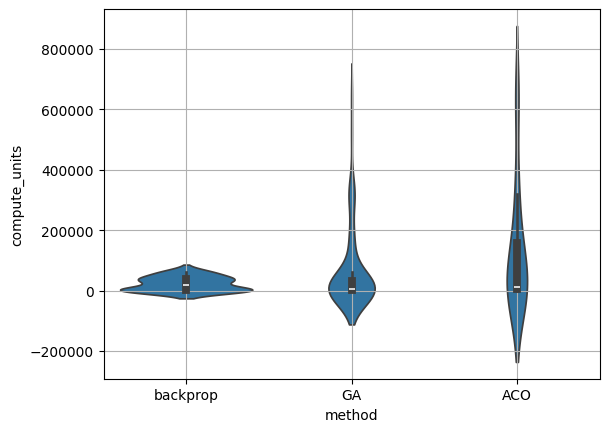

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=df, x="method", y="compute_units")
plt.grid()
plt.show()